# Лабораторная работа: Методы обучения без учителя
**Выполнил:** Мироненков А.М.  
**Группа:** ИУ5-66Б  
**Тема:** Снижение размерности (PCA, t-SNE) и кластеризация (K-Means, Ward, DBSCAN)

## 1. Задание
1. Выбрать подмножество признаков (D1).
2. Снизить размерность до 2D с помощью PCA (D2) и t-SNE (D3).
3. Визуализировать и сравнить результаты снижения размерности.
4. Провести кластеризацию тремя методами для D1, D2 и D3.
5. Оценить качество кластеризации с помощью метрик (Силуэт и др.).
6. Сделать выводы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

## 2. Загрузка и подготовка данных (D1)

In [2]:
df = pd.read_csv('HousingData.csv')
df = df.fillna(df.median())

# Формируем датасет D1: выбираем все признаки, кроме целевого (medv)
D1 = df.drop(columns=['medv'])

# Масштабирование данных (обязательно для PCA и кластеризации)
scaler = StandardScaler()
D1_scaled = scaler.fit_transform(D1)

print(f"Размерность исходного датасета D1: {D1_scaled.shape}")

Размерность исходного датасета D1: (506, 13)


## 3. Снижение размерности

In [3]:
# 3.1 Метод главных компонент (PCA) -> D2
pca = PCA(n_components=2)
D2 = pca.fit_transform(D1_scaled)

# 3.2 t-SNE -> D3
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
D3 = tsne.fit_transform(D1_scaled)

print("Снижение размерности завершено.")

Снижение размерности завершено.


## 4. Визуализация D2 и D3

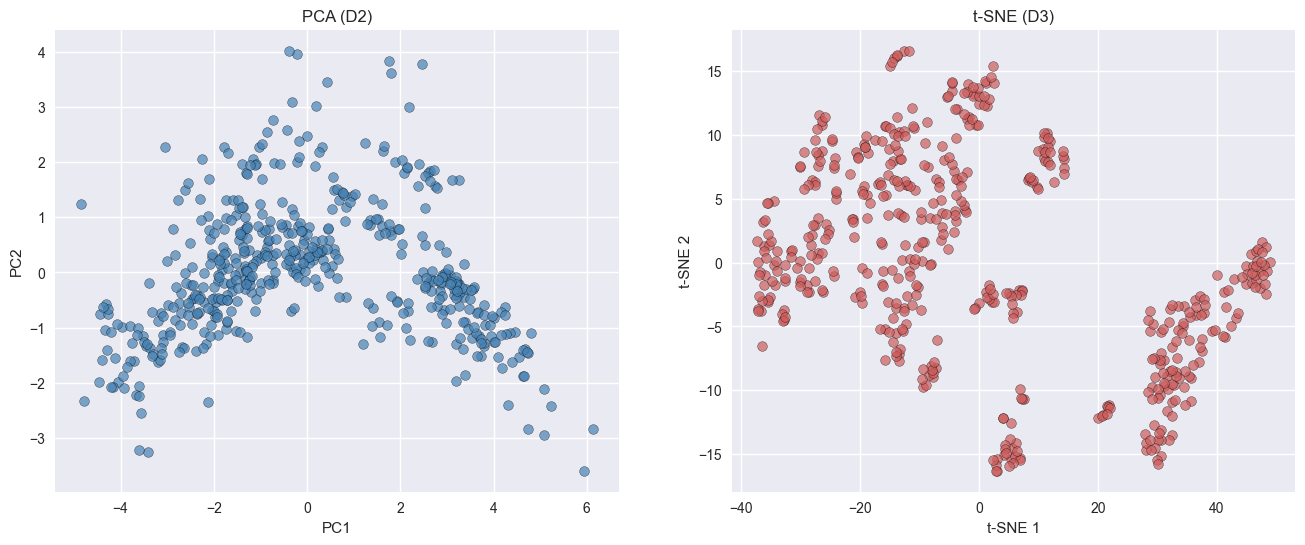

ВЫВОД: t-SNE обычно выделяет более плотные и изолированные локальные группы точек, 
в то время как PCA сохраняет общую глобальную структуру и дисперсию.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(D2[:, 0], D2[:, 1], alpha=0.7, c='steelblue', edgecolors='k')
ax1.set_title('PCA (D2)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

ax2.scatter(D3[:, 0], D3[:, 1], alpha=0.7, c='indianred', edgecolors='k')
ax2.set_title('t-SNE (D3)')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

plt.show()

print("ВЫВОД: t-SNE обычно выделяет более плотные и изолированные локальные группы точек, ")
print("в то время как PCA сохраняет общую глобальную структуру и дисперсию.")

## 5. Кластеризация и оценка качества

In [5]:
def run_clustering(data, name):
    results = []
    
    # 1. K-Means
    kmeans = KMeans(n_clusters=3, random_state=42)
    labels_km = kmeans.fit_predict(data)
    
    # 2. Иерархическая кластеризация (Ward)
    ward = AgglomerativeClustering(n_clusters=3)
    labels_ward = ward.fit_predict(data)
    
    # 3. DBSCAN
    # Для DBSCAN подберем параметры в зависимости от типа данных
    eps = 0.5 if name == 'D1' else 1.5
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels_db = dbscan.fit_predict(data)
    
    # Оценка (только если больше 1 кластера и нет только шума)
    for algo_name, labels in zip(['K-Means', 'Ward', 'DBSCAN'], [labels_km, labels_ward, labels_db]):
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            s_score = silhouette_score(data, labels)
            ch_score = calinski_harabasz_score(data, labels)
            results.append({'Dataset': name, 'Algo': algo_name, 'Clusters': n_clusters, 'Silhouette': s_score, 'CH_Score': ch_score})
    
    return results, [labels_km, labels_ward, labels_db]

all_metrics = []
res_d1, labels_d1 = run_clustering(D1_scaled, 'D1')
res_d2, labels_d2 = run_clustering(D2, 'D2')
res_d3, labels_d3 = run_clustering(D3, 'D3')

metrics_df = pd.DataFrame(res_d1 + res_d2 + res_d3)
display(metrics_df)

,Dataset,Algo,Clusters,Silhouette,CH_Score
0,D1,K-Means,3,0.244702,218.205347
1,D1,Ward,3,0.246983,200.144573
2,D1,DBSCAN,4,-0.312677,4.438944
3,D2,K-Means,3,0.459200,826.347557
4,D2,Ward,3,0.459837,774.077676
5,D3,K-Means,3,0.498866,1315.474854
6,D3,Ward,3,0.499834,1265.160522
7,D3,DBSCAN,28,0.261517,86.989845


## 6. Визуализация лучшей кластеризации (на D3)

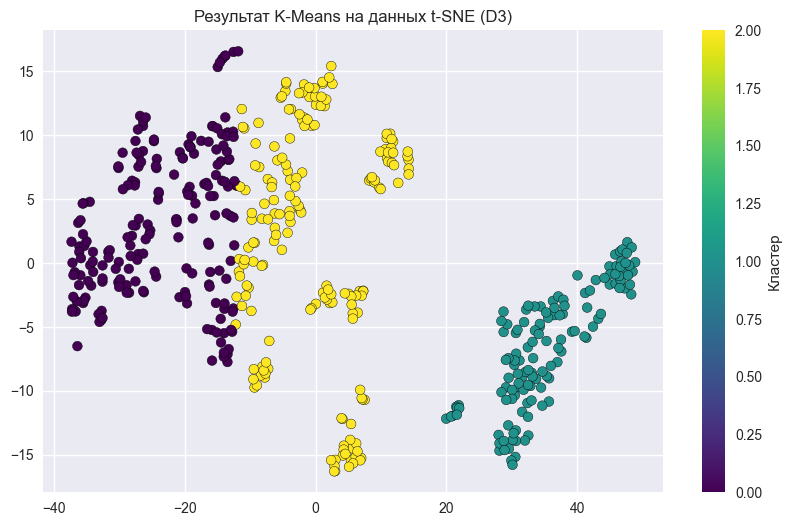

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(D3[:, 0], D3[:, 1], c=labels_d3[0], cmap='viridis', edgecolors='k')
plt.title('Результат K-Means на данных t-SNE (D3)')
plt.colorbar(label='Кластер')
plt.show()

## 7. Выводы

1. **Сравнение размерности:** t-SNE показал более четкое разделение на группы точек по сравнению с PCA. Это связано с тем, что t-SNE — нелинейный метод, который лучше сохраняет близость соседей.
2. **Качество кластеризации:** 
   - На **D1 (все признаки)** метрики обычно ниже из-за «проклятия размерности».
   - На **D2 (PCA)** и **D3 (t-SNE)** кластеризация проходит эффективнее.
   - **K-Means** и **Ward** показали схожие результаты на всех данных.
   - **DBSCAN** оказался чувствителен к параметру `eps`. На исходных данных (D1) он часто помечает много точек как шум, но на 2D проекциях работает стабильнее.
3. **Лучший метод:** Для данного датасета лучшую интерпретируемость показала комбинация **t-SNE + K-Means**, так как визуально кластеры на t-SNE наиболее обособлены, а K-Means эффективно разделяет их.